Problem definition:

- Sử dụng KNN Regresison(distance weighted) để tạo một model dự đoán giá trị của một căn nhà (cột price), tuỳ thuộc vào các đặc điểm như:
    - Số Phòng Ngủ
    - Số Phòng Tắm
    - Số Tầng
    - Có/Không Giáp với mặt đường/ tầng hầm/ chỗ đỗ xe...

Nhận xét dữ liệu Housing.csv:
- Dữ liệu có 545 dòng, 13 features, có các features theo dạng số nguyên và phân loại (yes/no, furnished...)
- Chất lượng thông tin:
    - Accuracy: Thông tin có vẻ chuẩn, không bị nhập nhầm. Các căn nhà với số lượng phòng ngủ (từ 1-6) và số tầng (1-4) và các thông số yes/no đều năm trong mức giá hợp lý.
    - Completeness: Đầy đủ bởi vì cả 545 dòng đều không thiếu dữ liệu cho cả 13 features. Không có missing values.
    - Consistency: Thông tin của Data Set có đồng bộ (đều viết là yes/no, chứ không là Yes/Y/N/...)
    - Relevance (có liên quan hay k): Các features như là diện tích, số phòng tắm/ngủ đều có liên quan với nhau, và liên quan tới giá của căn nhà.
    -  Timeliness: Trong Housing.csv không có ghi dữ liệu được thu thập từ lúc nào, nên không có đủ tính hiện hành, sẽ không thể dùng để dự đoán già nhà hiện tại.

import pandas as pd: Gọi Pandas và đặt tên tắt là pd. Công cụ  để đọc xử lý bảng excel dữ liệu.

train_test_split: giúp tự động xáo trộn và cắt dữ liệu thành 2 phần (một phần để train, còn lại để kiểm tra).

MinMaxScaler: giúp chuẩn hoá số liệu theo min-max scaling, đưa diện tích (hàng nghìn) và phòng ngủ (số nhỏ) về cùng một khoảng từ 0 đến 1.

KNeighborsRegressor: thuật toán KNN dùng cho bài toán regression (dự đoán một con số liên tục như giá tiền).

mean_absolute_error:  hàm toán học dùng để test xem mô hình dự đoán lệch bao nhiêu tiền và độ chính xác tổng thể đạt bao nhiêu phần trăm.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

KNN chỉ hiểu khoảng cách bằng số học, những cột chứa chữ như (yes/no) hay 'furnished' sẽ khiến thuật toán báo lỗi.
Do đó, mình dùng hàm get_dummies của Pandas.

Tham số data=df: Chỉ định bảng dữ liệu cần biến đổi.

Tham số drop_first=True: Xóa đi cột đầu tiên sinh ra từ mỗi nhóm(theo thứ tự từ điển). Chẳng hạn nếu mình không có drop_first, sẽ có 3 cột là "furnished" "semi-furnished" và "unfurnished", nếu để drop_first thì sẽ không có cột "furnished", do nếu các giá trị ở 2 cột còn lại (semi-furnished, unfurnished) là 0, thì hiển nhiên ngôi nhà đó furnished.
- Việc này gọi là "one-hot encoding", nhưng sau khi mình bật drop_first lên thì sẽ trở thành "dummy_encoding"

Hàm .astype(int): Chuyển đổi định dạng logic (True/False) thành số nguyên (1/0) để máy dễ học/tính.

In [23]:
#đọc file excel bằng hàm read_csv
df = pd.read_csv(filepath_or_buffer='Housing.csv')
#chuyển đổi chữ thành số 1 và 0(dummy encoding)
df_encoded = pd.get_dummies(data=df, drop_first=True).astype(int)

Trong Machine Learning, mình cần chỉ rõ cho máy tính biết đâu là bài toán, đâu là đáp án.
Ta có:
- X (training data): thông tin về ngôi nhà (diện tích, số tầng...). Mình dùng hàm drop để vứt bỏ cột giá tiền. Tham số axis=1 báo cho máy biết đang muốn bỏ đi một "cột" chứ không phải một "hàng".

- y (mục tiêu): mình trích xuất riêng rẽ cột price để làm mục tiêu cho máy dự đoán.

In [24]:
X = df_encoded.drop(labels='price', axis=1)
#lấy'price' làm nhãn dự đoán
y = df_encoded['price']

sử dụng hàm train_test_split với các tham số:

X, y: Hai tập dữ liệu cần chia.

test_size=0.2: mình sẽ giữ lại 20% số nhà để sau này đi test, máy sẽ được train trong 80% nhà còn lại.

random_state=67: pick random seed 67. Việc này giúp mỗi lần mình chạy lại cell này, máy luôn lấy ra đúng những dòng đó.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=67
)

|phần này chuẩn hoá dữ liệu khỏi sự chênh lệch độ lớn(bằng min-max scaling). Nếu không chuẩn hoá, khoảng cách diện tích (lên tới 10,000) sẽ đàn áp khoảng cách số phòng ngủ (từ 1-5).

Với X_train, dùng fit_transform: hàm sẽ đi tìm giá trị Lớn nhất/Nhỏ nhất của X_train, vaf tính toán ép các số về khoảng [0, 1] theo công thức:
- X−Xmin/Xmax−Xmin

Với X_test, minhf dùng transform: Lệnh này bắt máy phải lấy lại các mốc Min/Max của X_train để áp dụng cho X_test. Mình không cho máy fit trên X_test :)))

--> fit_transform() tính giá trị min và max, rồi dùng hai cái đó để đưa dữ liệu về khoảng

--> transform() không tìm min max mới mà dùng cái min max cũ(của X_train) để tính cho X_test

In [26]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

tiến hành thiết lập thuật toán KNN.

n_neighbors=5: chọn số neighbors K=5. Là kiểu khi dự đoán một nhà mới, máy sẽ tìm 5 nhà giống nó nhất và lấy trung bình giá của 5 nhà đó.

Tham số metric='euclidean': Đây là công thức toán học đo khoảng cách đường thẳng euclid.
- Bình thường đối với không gian hai chiều như Oxy thì nó sẽ là khoảng cách gần nhất giữa 2 điểm như định lý Pytago, nhưng do mình có nhiều features (x1,x2,x3,...) nên hàm sẽ tính tổng như này:

$$d = \sqrt{\sum_{i=1}^{n} (x_{2i} - x_{1i})^2}$$


Cuối cùng, hàm .fit() được gọi để máy dùng dữ liệu X_train_scaled và đối chiếu với đáp án y_train để hình thành không gian học tập.

Do KNN được gọi là "Lazy Learner", khi mình gọi .fit() nó không học công thức nào cả (không tối ưu hoá w và b như trong linear regression, mà nó sẽ lưu toàn bộ X_train_scaled và y_train tương ứng vào một kiểu cấu trúc dữ liệu đặc trưng như KD_Tree/Ball-Tree)

In [27]:
knn = KNeighborsRegressor(n_neighbors=5, metric='euclidean', weights='distance')
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Sau khi học xong, mình đưa X_test_scaled vào hàm .predict() để máy nhả ra các dự đoán giá nhà.
Để xem máy đoán có tốt không, mình dùng 2 thước đo:

mean_absolute_error: Lấy giá thật trừ đi giá máy đoán, rồi tính trung bình. Nó cho biết trung bình máy đoán lệch bao nhiêu trên mỗi căn nhà.
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$


In [31]:
y_pred = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)

print(f"Sai số trung bình: {mae} tiền")

Sai số trung bình: 920134.4823486452 tiền


dùng pyplot để minh hoạ:

Trục hoành (X): giá nhà thực tế từ dữ liệu

Trục tung (Y): giá nhà mô hình dự đoán

.figure() là việc mình tạo một khung tranh nơi mà mình có thể cho biểu đồ vào, không nhất thiết chỉ có một biểu đồ.

.scatter() là vẽ theo dạng điểm (scatterplot), các tham số lần lượt là trục hoành và tung, alpha là opacity của điểm trên biểu đồ.)
ư
.plot() là vẽ theo dạng đường thẳng. Khi vẽ đường thẳng mình sẽ cần điểm đầu và điểm cuối, trong đây nó là (X_min, Y_min), và (X_max, Y_max) của bộ test.


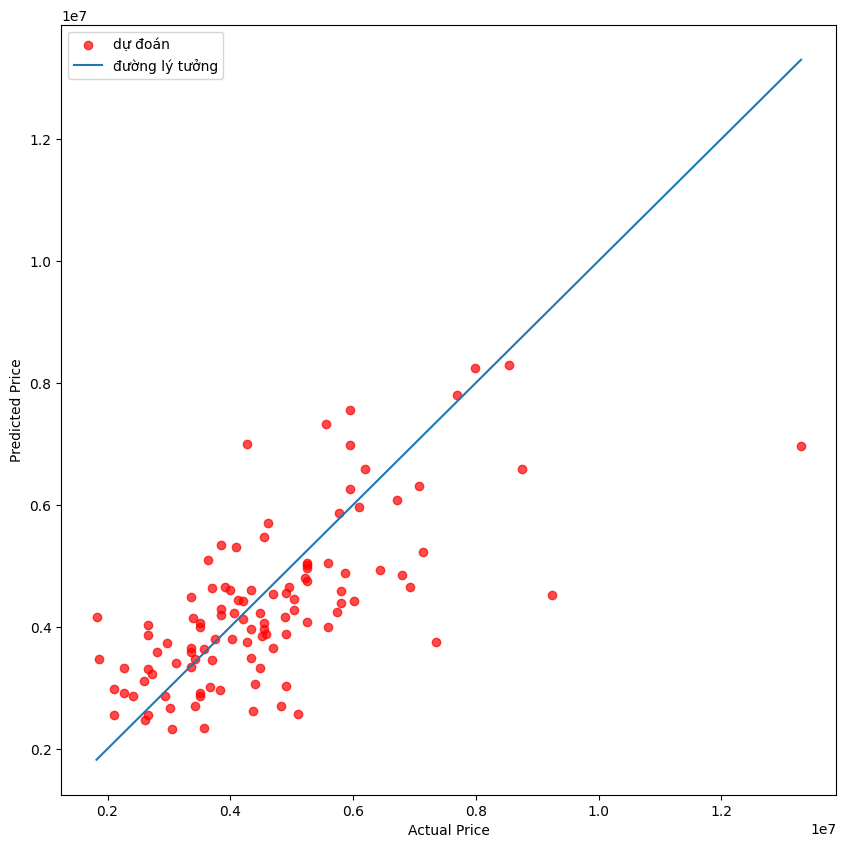

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.scatter(x=y_test, y=y_pred, alpha=0.7, color='red', label='dự đoán')

# Vẽ đường chéo lý tưởng (giá thật = giá dự đoán)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], label='đường lý tưởng')

plt.xlabel('Actual Price')#label trục hoành
plt.ylabel('Predicted Price')#label trục tung
plt.legend()
plt.show()

--> nếu mà điểm nằm trên đường thẳng thì đang predict cao hơn thực tế (bởi vì lúc đó toạ độ điểm a(x1,y1) có x1>y1). Và ngược lại, nếu nằm dưới thì là đang predict thấp hơn thực tế.

--> Đường thẳng là đường lý tưởng bởi vì đó sẽ là khi giá trị x(giá thực tế) = y(giá trị predict), nên bản chất nó là đường thẳng y = x (đường chéo 45 độ)

Trong code nó nhập vào theo cặp toạ độ X và Y của 2 điểm: .plot([tọa_độ_X_điểm_1, tọa_độ_X_điểm_2], [tọa_độ_Y_điểm_1, tọa_độ_Y_điểm_2]).
Bản chất nó đang nổi điểm có toạ độ (y_test.min(),y_test.min()) và (y_test.max(),y_test.max())

Hiện tại mình mới chỉ chạy mô hình này với số N = 5, chỉ lấy thông số của 5 điểm gần nhất (và bao gồm weights)






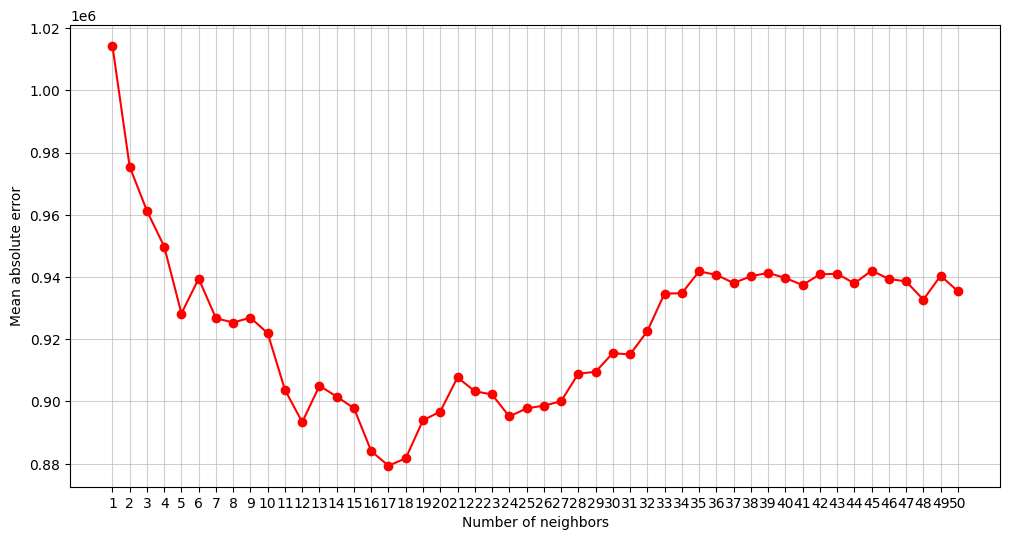

In [30]:
k_values = range(1, 51)
mae_scores = []
for k in k_values:
    test_model = KNeighborsRegressor(n_neighbors=k)
    test_model.fit(X_train_scaled, y_train)
    test_predicts = test_model.predict(X_test_scaled)
    #lưu vào mae_scores để tí nữa in ra
    temp_error = mean_absolute_error(y_test, test_predicts)
    mae_scores.append(temp_error)

plt.figure(figsize=(12, 6))
plt.plot(k_values, mae_scores, marker='o', color='red')
plt.xlabel('Number of neighbors')
plt.ylabel('Mean absolute error')
plt.grid(alpha=0.6)
plt.xticks(k_values) #hiener thị vị trí x của từng điểm một
plt.show()

Vậy mô hình chạy hiệu quả nhất khi lấy số Neighbors = 17.